# Моделирование A/B - тестирования на данных мобильной игры Cookie Cats

Cookie Cats - мобильная игра free-to-play, данные о пользовательском поведении взяты с Kaggle https://www.kaggle.com/datasets/mursideyarkin/mobile-games-ab-testing-cookie-cats

Источник утверждает, что это
оригинальные данные после создания двух рандомных выборок из клиентов игры. Выборки были сформированы версиями: одним пользователям предлагался первый boss level на уровне 30, а другой группе - на уровне 40.

Эти выборки выступают группами для тестирования в данном
исследовании. Выборки уже были сформированы создателями датасета,
поэтому в данной работе рассматривается только построение решающей
статистики и тестирование метрик.

## Импорт биболиотек и датасета

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import shapiro, norm
from scipy.stats import mannwhitneyu
from scipy.stats import chi2_contingency
from tqdm.auto import tqdm
plt.style.use('ggplot')

In [2]:
df = pd.read_csv('cookie_cats.csv')
df

,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True
...,...,...,...,...,...
90184,9999441,gate_40,97,True,False
90185,9999479,gate_40,30,False,False
90186,9999710,gate_30,28,True,False
90187,9999768,gate_40,51,True,False


# Exploratory Data Analysis

## Описание столбцов и проверка типов данных

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90189 entries, 0 to 90188
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   userid          90189 non-null  int64 
 1   version         90189 non-null  object
 2   sum_gamerounds  90189 non-null  int64 
 3   retention_1     90189 non-null  bool  
 4   retention_7     90189 non-null  bool  
dtypes: bool(2), int64(2), object(1)
memory usage: 2.2+ MB


В датасете содержатся 6 столбцов:
userid - уникальный id пользователя
version - gate_30 или gate_40 - как раз отвечает за наши группы тестирования
sum_gamerounds - суммарное количество пройденных уровней для пользователя за первые 14 дней
retention_1 - бинарная переменная возврата в приложение спустя 1 день после установки
retention_7 - возврат на 7 день после установки

## Пропуски

In [4]:
df.isna().sum()

userid            0
version           0
sum_gamerounds    0
retention_1       0
retention_7       0
dtype: int64

Пропусков нет

In [5]:
df.groupby("version").agg({"sum_gamerounds":["count","sum","mean","min","max"]})

sum_gamerounds                               
                 count      sum       mean min    max
version                                              
gate_30          44700  2344795  52.456264   0  49854
gate_40          45489  2333530  51.298776   0   2640

Уже по предварительной оценке версий видно, что в группе gate_30 максимальное значение достигает почти 50 тысяч, это, очевидно, выброс

## Выбросы

Проверим распределение данных, минимальные и максимальные значения

In [6]:
df.describe()

,userid,sum_gamerounds
count,9.018900e+04,90189.000000
mean,4.998412e+06,51.872457
std,2.883286e+06,195.050858
min,1.160000e+02,0.000000
25%,2.512230e+06,5.000000
50%,4.995815e+06,16.000000
75%,7.496452e+06,51.000000
max,9.999861e+06,49854.000000


Построим перцентильную кривую, чтобы понять, в каком перцентиле есть отклонения

In [7]:

percentiles = [0, 1, 5, 10, 25, 50, 75, 90, 95, 99, 99.5, 99.9, 100]

values = np.percentile(df['sum_gamerounds'], percentiles)

for p, v in zip(percentiles, values):
    print(f"{p}-й перцентиль: {v}")

0-й перцентиль: 0.0
1-й перцентиль: 0.0
5-й перцентиль: 1.0
10-й перцентиль: 1.0
25-й перцентиль: 5.0
50-й перцентиль: 16.0
75-й перцентиль: 51.0
90-й перцентиль: 134.0
95-й перцентиль: 221.0
99-й перцентиль: 493.0
99.5-й перцентиль: 623.0599999999977
99.9-й перцентиль: 1073.6240000000107
100-й перцентиль: 49854.0


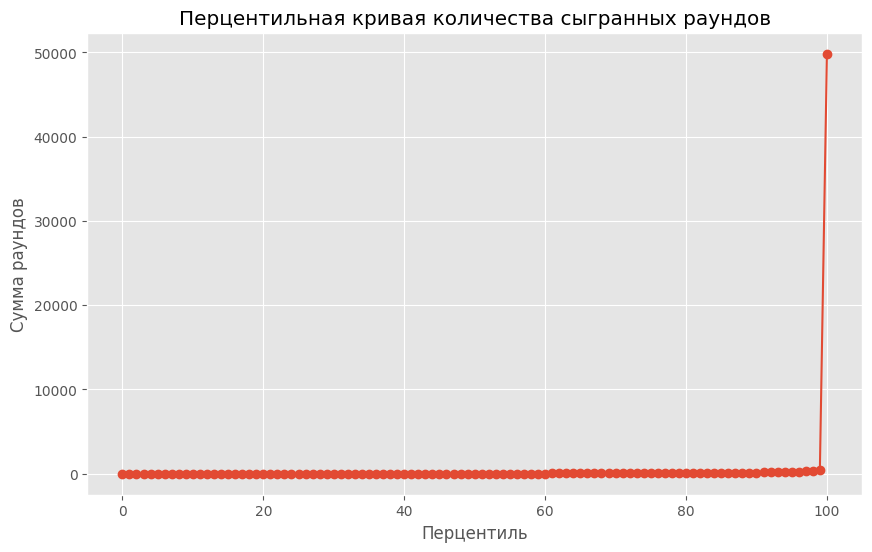

In [8]:
percentiles = np.arange(0, 101, 1)
values = np.percentile(df['sum_gamerounds'], percentiles)

plt.figure(figsize=(10, 6))
plt.plot(percentiles, values, marker='o')
plt.title('Перцентильная кривая количества сыгранных раундов')
plt.xlabel('Перцентиль')
plt.ylabel('Сумма раундов')
plt.grid(True)
plt.show()

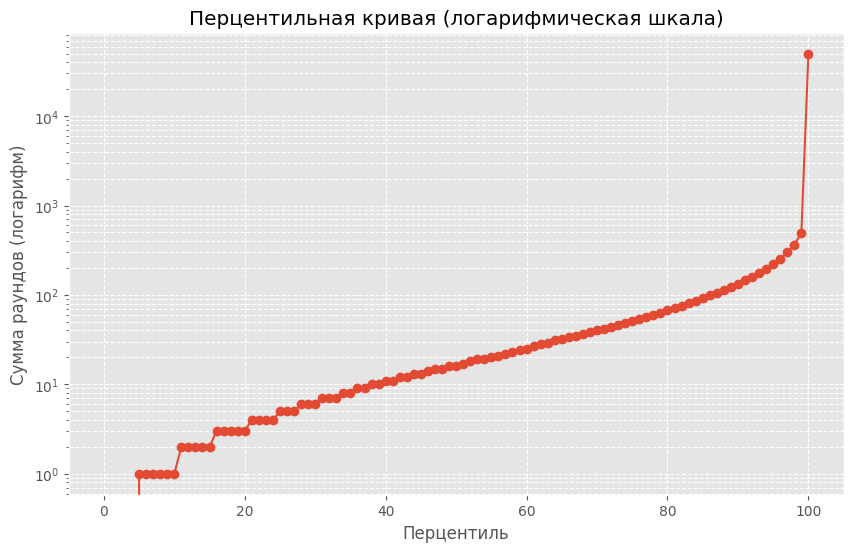

In [9]:
plt.figure(figsize=(10, 6))
plt.plot(percentiles, values, marker='o')
plt.yscale('log')
plt.title('Перцентильная кривая (логарифмическая шкала)')
plt.xlabel('Перцентиль')
plt.ylabel('Сумма раундов (логарифм)')
plt.grid(True, which="both", ls="--")
plt.show()

Очевидно, что есть какие-то аномально большие значения

In [10]:
df[df['sum_gamerounds']>=3000]

,userid,version,sum_gamerounds,retention_1,retention_7
57702,6390605,gate_30,49854,False,True


Избавимся от 50 тысяч раундов

In [11]:
df=df[df['sum_gamerounds']<3000] #дропаем

Перцентили после очистки выброса

In [12]:
percentiles = [0, 1, 5, 10, 25, 50, 75, 90, 95, 99, 99.5, 99.9, 100]

values = np.percentile(df['sum_gamerounds'], percentiles)

for p, v in zip(percentiles, values):
    print(f"{p}-й перцентиль: {v}")

0-й перцентиль: 0.0
1-й перцентиль: 0.0
5-й перцентиль: 1.0
10-й перцентиль: 1.0
25-й перцентиль: 5.0
50-й перцентиль: 16.0
75-й перцентиль: 51.0
90-й перцентиль: 134.0
95-й перцентиль: 221.0
99-й перцентиль: 493.0
99.5-й перцентиль: 623.0
99.9-й перцентиль: 1071.065000000046
100-й перцентиль: 2961.0


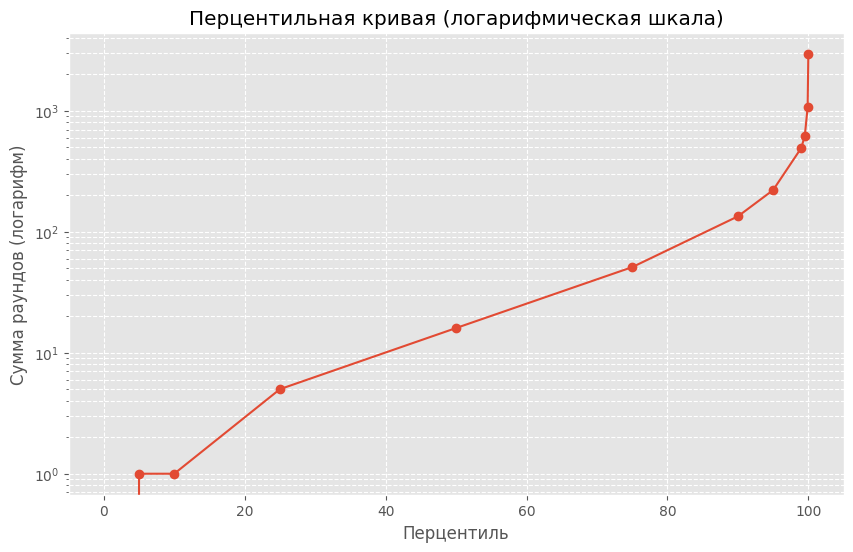

In [13]:
plt.figure(figsize=(10, 6))
plt.plot(percentiles, values, marker='o')
plt.yscale('log')
plt.title('Перцентильная кривая (логарифмическая шкала)')
plt.xlabel('Перцентиль')
plt.ylabel('Сумма раундов (логарифм)')
plt.grid(True, which="both", ls="--")
plt.show()

## Проверка распределения

c:\Users\sigae\miniconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:573: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 90188.
  res = hypotest_fun_out(*samples, **kwds)


Не нормальное распределение.


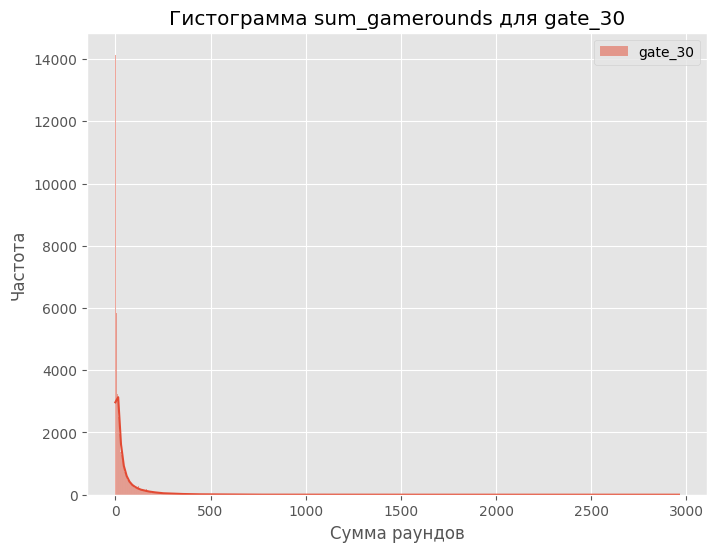

In [14]:
metric_data = df['sum_gamerounds']

# Применяем тест Шапиро-Уилка
stat, p = shapiro(metric_data)

alpha = 0.05
if p > alpha:
    print("Нормальное распределение.")
else:
    print("Не нормальное распределение.")

import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8, 6))
sns.histplot(df['sum_gamerounds'], kde=True, label='gate_30')
plt.title('Гистограмма sum_gamerounds для gate_30')
plt.xlabel('Сумма раундов')
plt.ylabel('Частота')
plt.legend()
plt.savefig('shapiro_histogram.png')
plt.show()

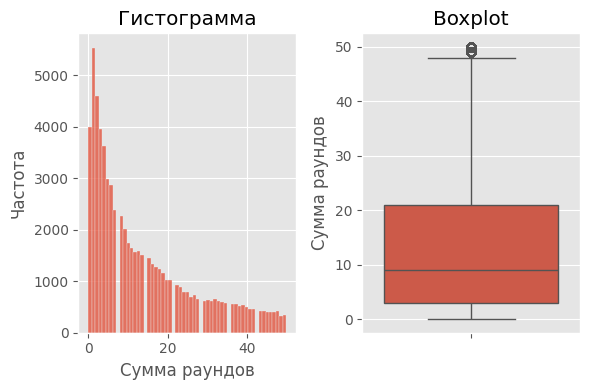

In [15]:
plt.figure(figsize = (6,4))

plt.subplot(1,2,1)
sns.histplot(x = 'sum_gamerounds', data = df[df['sum_gamerounds']<51])
plt.title('Гистограмма')
plt.xlabel('Сумма раундов')
plt.ylabel('Частота')

plt.subplot(1,2,2)
sns.boxplot(y= 'sum_gamerounds', data = df[df['sum_gamerounds']<51])
plt.title ('Boxplot')
plt.ylabel('Сумма раундов')
plt.tight_layout()

Распределение ненормальное

# А/Б тестирование метрика вовлеченность

Мобильные игры с точки зрения продуктовой аналитики имеют ряд
особенностей: особая сегментация пользователей, механики получения
прибыли, ключевые показатели.


Для игр F2P (free to play), которые
изначально бесплатны для всех игроков, характерна ситуация, в которой
небольшая группа пользователей приносит основную часть дохода. Такие
игроки, как правило, составляют около 1–2% от общего количества, но доля
дохода от взаимодействий с ними может превышать 75% всех доходов игры.

Бизнес-модель игр F2P обычно выстраивается на получении
основного дохода от внутриигровых покупок пользователей: предметов,
игровой валюты, платных подписок, а также от показа рекламы. При этом,
ключевыми метриками являются вовлеченность и удержание.

В данных о пользователях Cookie Cats содержатся метрики возвращаемости (retention_1, retention_7) и вовлеченности (сумма раундов)


## Тест Манна-Уитни

Тк распределение ненормальное имеет смысл использовать тест манна уитни

In [16]:
gate_30 = df[df['version'] == 'gate_30']
gate_40 = df[df['version'] == 'gate_40']

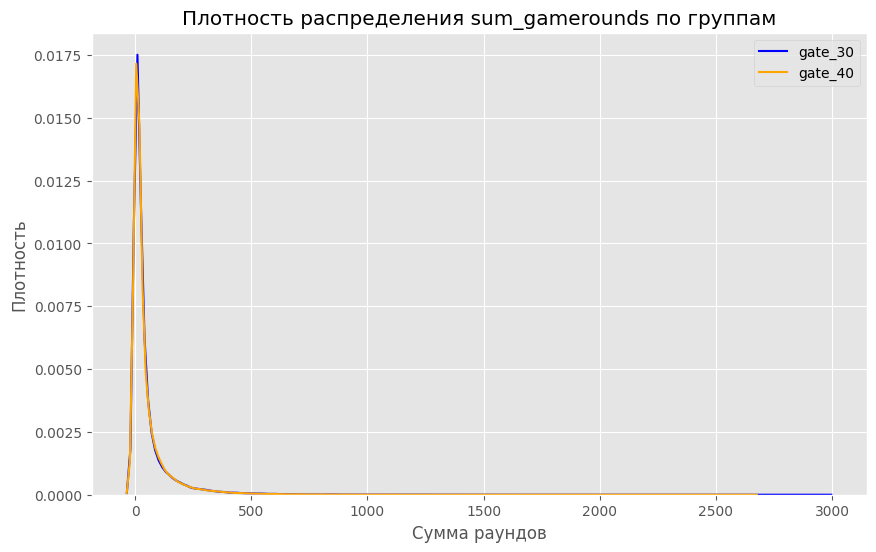

In [17]:
# Графики плотности для сравнения форм распределений
plt.figure(figsize=(10, 6))
sns.kdeplot(data=gate_30['sum_gamerounds'], label='gate_30', color='blue')
sns.kdeplot(data=gate_40['sum_gamerounds'], label='gate_40', color='orange')
plt.title('Плотность распределения sum_gamerounds по группам')
plt.xlabel('Сумма раундов')
plt.ylabel('Плотность')
plt.legend()
plt.savefig('density_plot.png')
plt.show()

Н(0) - нет значимых различий между группами А и Б

Н(1) - различия есть

In [18]:
a = df[df['version'] == 'gate_30']['sum_gamerounds']
b = df[df['version'] == 'gate_40']['sum_gamerounds']

stat, p = mannwhitneyu(a, b, alternative='two-sided')
print(f'Mann-Whitney U тест: статистика={stat}, p-value={p}')

Mann-Whitney U тест: статистика=1024285761.5, p-value=0.05089155279145376


Значение p-value составило 0.0508, что не отвергает нулевую гипотезу
на 5%-ом уровне значимости, соответственно, интерпретируется как
отсутствие статистически значимых различий в группах А и Б.

## Бутстрап

Более точный способ: использование бутстрапа

In [19]:
def get_bootstrap(
    data_column_1,
    data_column_2,
    boot_it = 1000,
    statistic = np.mean,
    bootstrap_conf_level = 0.95
):
    boot_len = max([len(data_column_1), len(data_column_2)])
    boot_data = []
    for i in tqdm(range(boot_it)):
        samples_1 = data_column_1.sample(
            boot_len,
            replace = True
        ).values

        samples_2 = data_column_2.sample(
            boot_len,
            replace = True
        ).values

        boot_data.append(statistic(samples_1-samples_2))
    pd_boot_data = pd.DataFrame(boot_data)

    left_quant = (1 - bootstrap_conf_level)/2
    right_quant = 1 - (1 - bootstrap_conf_level) / 2
    quants = pd_boot_data.quantile([left_quant, right_quant])

    p_1 = norm.cdf(
        x = 0,
        loc = np.mean(boot_data),
        scale = np.std(boot_data)
    )
    p_2 = norm.cdf(
        x = 0,
        loc = -np.mean(boot_data),
        scale = np.std(boot_data)
    )
    p_value = min(p_1, p_2) * 2

    # Визуализация
    _, _, bars = plt.hist(pd_boot_data[0], bins = 50)
    for bar in bars:
        if abs(bar.get_x()) <= quants.iloc[0][0] or abs(bar.get_x()) >= quants.iloc[1][0]:
            bar.set_facecolor('red')
        else:
            bar.set_facecolor('grey')
            bar.set_edgecolor('black')
    plt.vlines(quants,ymin=0,ymax=50,linestyle='--')
    plt.xlabel('Сумма раундов')
    plt.ylabel('Частота')
    plt.title("Распределение бутстреп")
    plt.show()

    return {"quants": quants,
            "p_value": p_value}

100%|██████████| 1000/1000 [00:02<00:00, 426.55it/s]


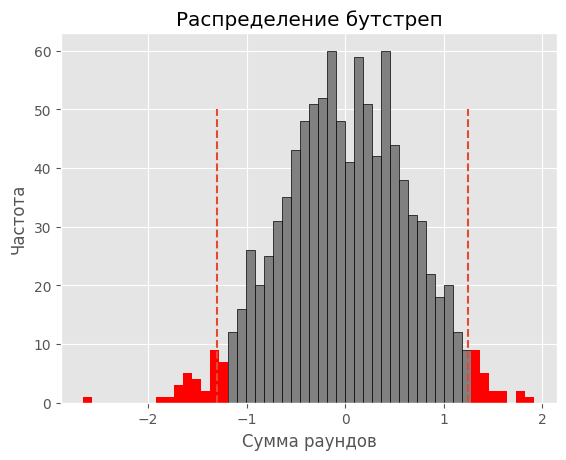

{'quants':               0
 0.025 -1.297430
 0.975  1.250557,
 'p_value': 0.9969259180168089}

In [20]:
get_bootstrap(a,b)

0 попадает в интервал так что Н0 не может отклониться

Для более точного анализа было принято решение построить также
график бутстрапированных медиан, поскольку среднее значение может давать
смещенные результаты из-за ненормального распределения данных.

In [21]:
def bootstrap(data, n_bootstrap=10000, func=np.median):
    boot_samples = []
    for _ in range(n_bootstrap):
        sample = np.random.choice(data, size=len(data), replace=True)
        boot_samples.append(func(sample))
    return np.array(boot_samples)
boot_a = bootstrap(a)
boot_b = bootstrap(b)
diff = boot_b - boot_a
low, high = np.percentile(diff, [5, 95])
print(f'90% доверительный интервал разницы: ({low}, {high})')

90% доверительный интервал разницы: (-1.0, 0.0)


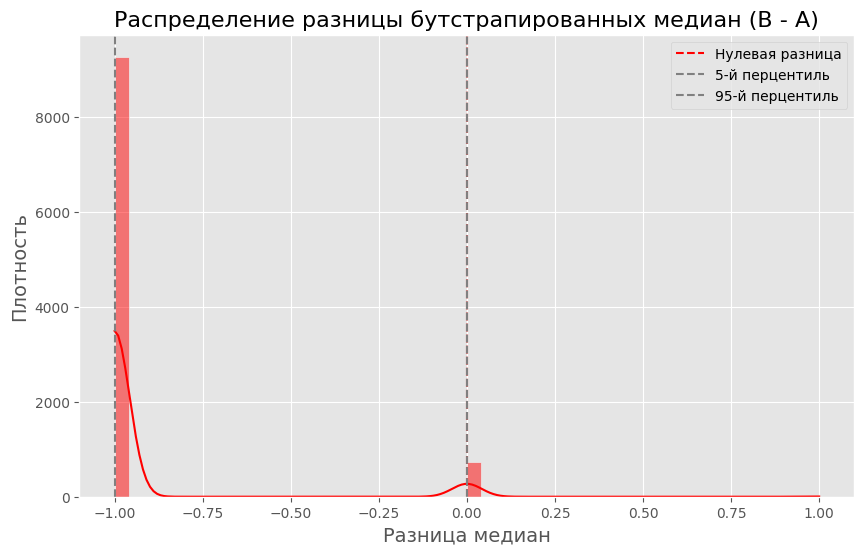

In [22]:
plt.figure(figsize=(10, 6))
sns.histplot(diff, kde=True, bins=50, color='red')
plt.axvline(x=0, color='red', linestyle='--', label='Нулевая разница')
plt.axvline(np.percentile(diff, 5), color='gray', linestyle='--', label='5-й перцентиль')
plt.axvline(np.percentile(diff, 95), color='gray', linestyle='--', label='95-й перцентиль')
plt.title('Распределение разницы бутстрапированных медиан (B - A)', fontsize=16)
plt.xlabel('Разница медиан', fontsize=14)
plt.ylabel('Плотность', fontsize=14)
plt.legend()
plt.grid(True)
plt.show()

В качестве вывода стоит выделить, что нуль попадает в интервал
распределения, соответственно, гипотеза об отсутствии статистически
значимых различий не может быть отклонена. Но основные значения
разницы медиан принимают значение -1, что предполагает отрицательный
сдвиг вследствие нововведения.

# А/Б тестирование метрика возвращаемость

Поскольку тестирование по основной количественной метрике не дало
значимых результатов, было целесообразно также проверить другие метрики,
представленные в датасете. Метрики retention_1 и retention_7 показывают,
вернулся ли пользователь в игру на 1 и 7 день после установки. Эти
переменные являются бинарными и для них применяется Хи-квадрат тест для
категориальных переменных.

## Хи-квадрат тест для категориальных переменных

In [27]:
def chi_squared_test(df, retention_column):
    contingency_table = pd.crosstab(df['version'], df[retention_column])
    print("Таблица сопряжённости:")
    print(contingency_table)

    chi2, p_value, dof, expected = chi2_contingency(contingency_table)
    print(f"\nХи-квадрат тест для {retention_column}:")
    print(f"p-value = {p_value:.5f}")

    if p_value < 0.05:
        print("Вывод: Различия между группами есть.")
    else:
        print("Вывод: Различий между группами нет.")

Проверка частот

In [29]:
chi_squared_test(df, 'retention_1')
chi_squared_test(df, 'retention_7')

Таблица сопряжённости:
retention_1  False  True 
version                  
gate_30      24665  20034
gate_40      25370  20119

Хи-квадрат тест для retention_1:
p-value = 0.07501
Вывод: Различий между группами нет.
Таблица сопряжённости:
retention_7  False  True 
version                  
gate_30      36198   8501
gate_40      37210   8279

Хи-квадрат тест для retention_7:
p-value = 0.00164
Вывод: Различия между группами есть.


По результатам тестирования нельзя отклонить нулевую гипотезу на
5%-ом уровне значимости для метрики retention_1, так как p-value составило
около 0,075, что превышает критическое значение 0,05.

Для метрики
retention_7 гипотеза Н(0) отклоняется, что сигнализирует о наличии
статистически значимых различий между группами. Судя по таблице
сопряженности, вернувшихся на седьмой день игроков в группе gate_40
меньше, чем в группе gate_30, следовательно, нововведение отрицательно
повлияло на эту метрику.

## Бутстрап для переменных отношений

Эти метрики можно также представить в качестве отношения
вернувшихся в игру пользователей ко всем пользователям группы.  Для таких метрик применим bootstrap,
рассчитанный по доверительному интервалу разницы долей.

In [30]:
def bootstrap_proportion_diff(df, retention_column, boot_it=10000, conf_level=0.95):
    group_a = df[df['version'] == 'gate_30'][retention_column]
    group_b = df[df['version'] == 'gate_40'][retention_column]

    boot_diffs = []
    for _ in tqdm(range(boot_it)):
        sample_a = np.random.choice(group_a, size=len(group_a), replace=True)
        sample_b = np.random.choice(group_b, size=len(group_b), replace=True)

        boot_diff = sample_b.mean() - sample_a.mean()
        boot_diffs.append(boot_diff)

    lower = np.percentile(boot_diffs, (1 - conf_level) / 2 * 100)
    upper = np.percentile(boot_diffs, (1 + conf_level) / 2 * 100)

    print(f"\nБутстрап разницы долей для {retention_column}:")
    print(f"Средняя разница: {np.mean(boot_diffs):.4f}")
    print(f"{int(conf_level*100)}% доверительный интервал: [{lower:.4f}, {upper:.4f}]")

    if lower > 0 or upper < 0:
        print("Вывод: Различия между группами значимы.")
    else:
        print("Вывод: Различия между группами НЕ значимы.")

    plt.hist(boot_diffs, bins=50, edgecolor='black')
    plt.axvline(x=lower, color='gray', linestyle='--')
    plt.axvline(x=upper, color='gray', linestyle='--')
    plt.title(f"Bootstrap разницы долей: {retention_column}")
    plt.show()

100%|██████████| 10000/10000 [00:14<00:00, 681.49it/s]



Бутстрап разницы долей для retention_1:
Средняя разница: -0.0060
95% доверительный интервал: [-0.0124, 0.0005]
Вывод: Различия между группами НЕ значимы.


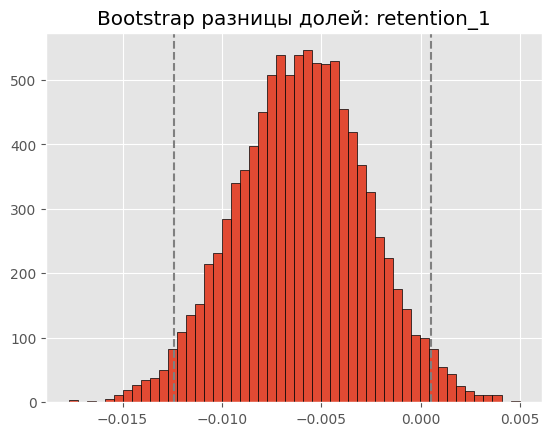

100%|██████████| 10000/10000 [00:14<00:00, 677.37it/s]



Бутстрап разницы долей для retention_7:
Средняя разница: -0.0082
95% доверительный интервал: [-0.0133, -0.0031]
Вывод: Различия между группами значимы.


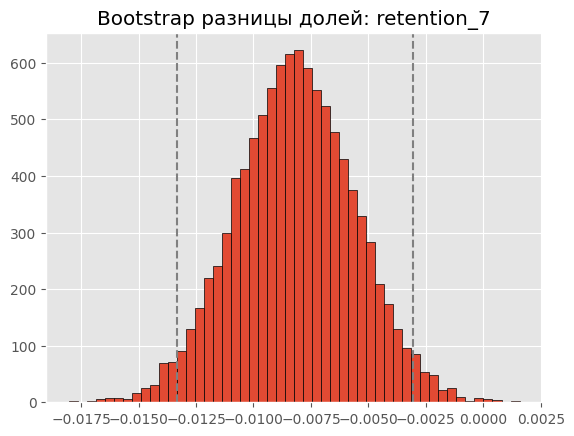

In [31]:
bootstrap_proportion_diff(df, 'retention_1')
bootstrap_proportion_diff(df, 'retention_7')

Таким образом, как видно по графикам, для разницы долей метрики
retention_1 нуль попадает в доверительный интервал, что не отклоняет
нулевую гипотезу об отсутствии различия между группами.

Для разницы
долей метрики retention_7 нулевая гипотеза отклоняется и значения в
основном лежат левее нуля на отрицательной части числовой прямой. Это
интерпретируется как наличие статистически значимого различия.

То есть,
доля вернувшихся на седьмой день игроков из группы Б значимо меньше, чем
доля пользователей группы А. Идентичные результаты были получены
Хи-квадрат тестом по этим метрикам.

# Вывод

Практическое исследование, проведенное на основе датасета «Cookie
Cats», позволило оценить влияние изменения условий игры — начала игры с
30-го или 40-го уровня — на поведение пользователей. В рамках
A/B-тестирования анализировались две ключевые метрики: сумма сыгранных
раундов (sum_gamerounds) как показатель вовлеченности и возвращаемость
(retention_1 и retention_7) как показатель удержания пользователей.

По метрике суммы сыгранных раундов тестирование с применением
непараметрического теста Манна-Уитни показало p-value 0,0508, что не
позволяет отвергнуть нулевую гипотезу об отсутствии различий на 5%-м
уровне значимости. Метод Bootstrap, использованный для анализа средних и
медиан, также продемонстрировал, что нулевое значение попадает в
доверительный интервал разницы, что указывает на отсутствие
статистически
значимых
различий.
Распределение
разницы
бутстрапированных медиан выявило небольшой отрицательный сдвиг (–1)
для группы gate_40, предполагая, что пользователи, начинающие с 40-го
уровня, в среднем проходят чуть меньше раундов, но этот эффект
незначителен. Таким образом, изменение уровня старта игры не оказало
существенного влияния на вовлеченность.

Анализ метрик возвращаемости выявил более выраженные результаты.
Для retention_1 (возвращаемость на первый день) тест Хи-квадрат показал
p-value 0,075, что превышает критическое значение 0,05, указывая на
отсутствие значимых различий между группами. В то же время для
retention_7 (возвращаемость на седьмой день) p-value составило 0,00164, что
позволяет отвергнуть нулевую гипотезу на 5%-м уровне. Таблица
сопряженности и Bootstrap-анализ разницы долей подтвердили, что в группе
gate_40 доля пользователей, вернувшихся на седьмой день, значимо ниже
(8279 против 8501 в gate_30). Это указывает на отрицательное влияние
нововведения на удержание.

С продуктовой точки зрения, результаты тестирования демонстрируют,
что начало игры с 40-го уровня не улучшает вовлеченность и снижает
удержание пользователей на седьмой день. Это может быть связано с тем, что
более высокий стартовый уровень воспринимается игроками как менее
мотивирующий или усложняет восприятие прогресса в игре. На основании
данных рекомендуется отказаться от внедрения gate_40 в текущем виде и
сосредоточиться на оптимизации других аспектов игры, таких как механики
вовлеченности или обучение новых пользователей.